<a href="https://colab.research.google.com/github/klu80082/2420080082-ML/blob/main/2420080082week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time
import warnings

warnings.filterwarnings('ignore')

In [2]:
print("=" * 50)
print("Part A: Data Loading and Preparation")
print("=" * 50)

print("Loading Fashion-MNIST dataset...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = fashion_mnist.data, fashion_mnist.target.astype(int)

# Reduce dataset size (for speed)
n_samples = 3000
np.random.seed(42)
indices = np.random.choice(X.shape[0], n_samples, replace=False)
X = X[indices]
y = y[indices]

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize
X_normalized = X / 255.0

Part A: Data Loading and Preparation
Loading Fashion-MNIST dataset...
Dataset shape: (3000, 784)
Number of samples: 3000
Number of features: 784
Number of classes: 10
Class distribution: [300 288 293 296 288 307 311 298 289 330]


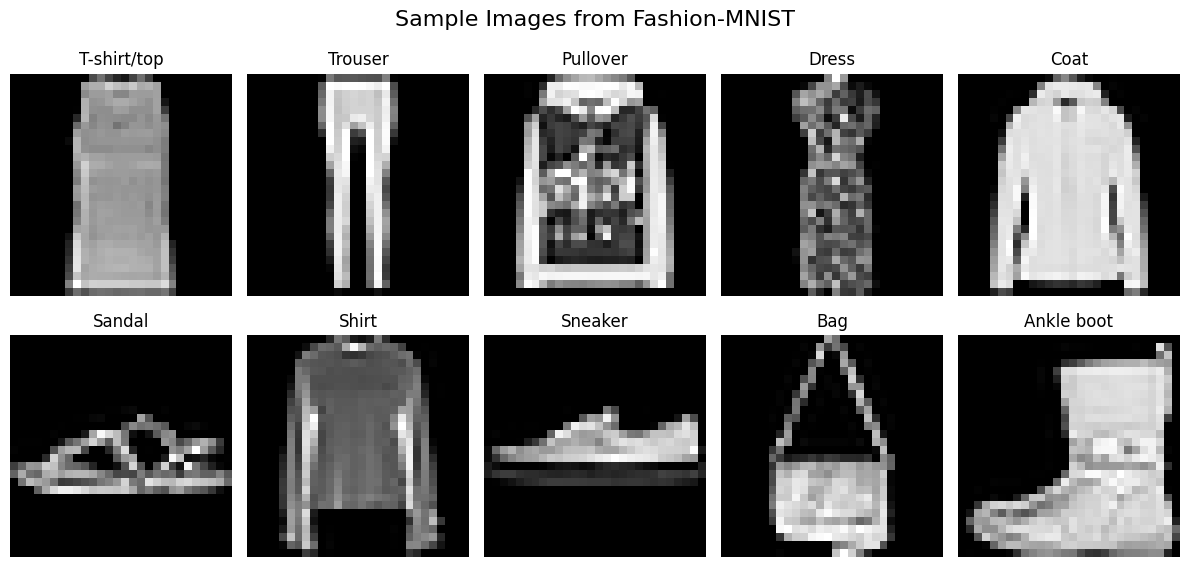

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'{class_names[i]}')
    axes[i].axis('off')

plt.suptitle('Sample Images from Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print("\n" + "=" * 50)
print("Part B: PCA Implementation")
print("=" * 50)

start_time = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)
pca_time = time.time() - start_time

print(f"PCA computation time: {pca_time:.2f} seconds")


Part B: PCA Implementation
PCA computation time: 0.42 seconds


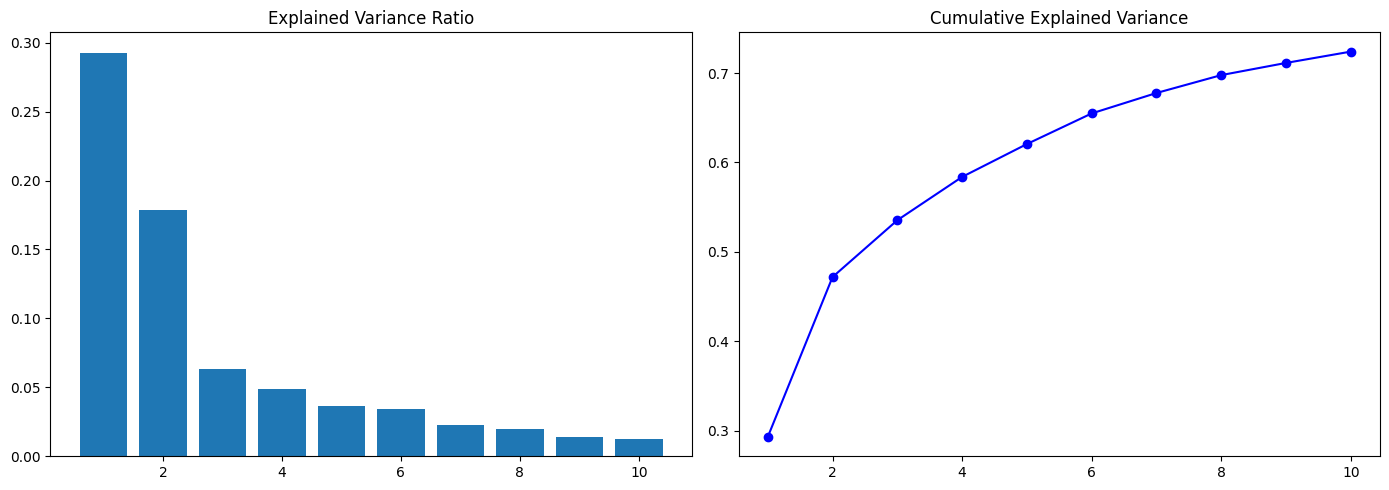

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca_full = PCA(n_components=10)
pca_full.fit(X_normalized)

axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
axes[0].set_title('Explained Variance Ratio')

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 11), cumulative_variance[:10], 'bo-')
axes[1].set_title('Cumulative Explained Variance')

plt.tight_layout()
plt.show()

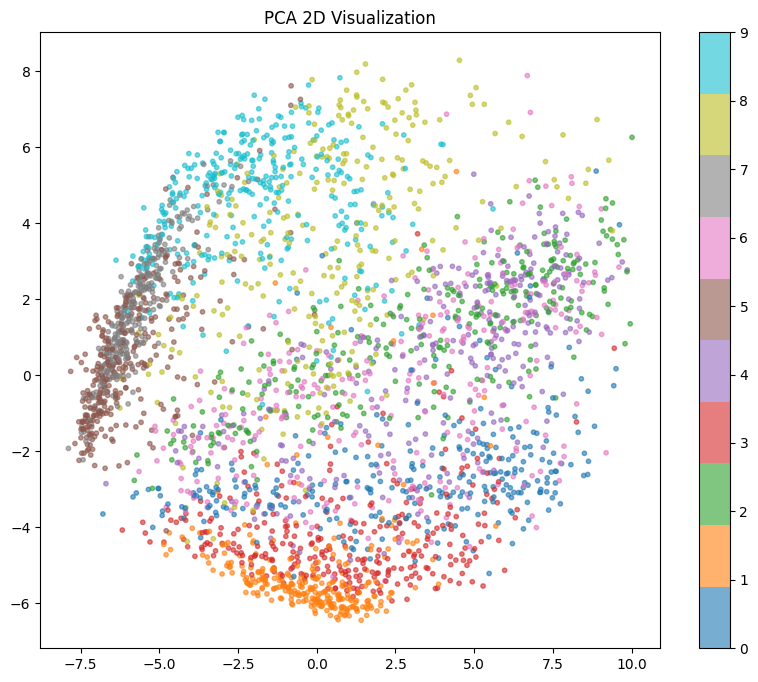

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)

ax.set_title('PCA 2D Visualization')
plt.colorbar(scatter)
plt.show()


Part C: t-SNE Implementation


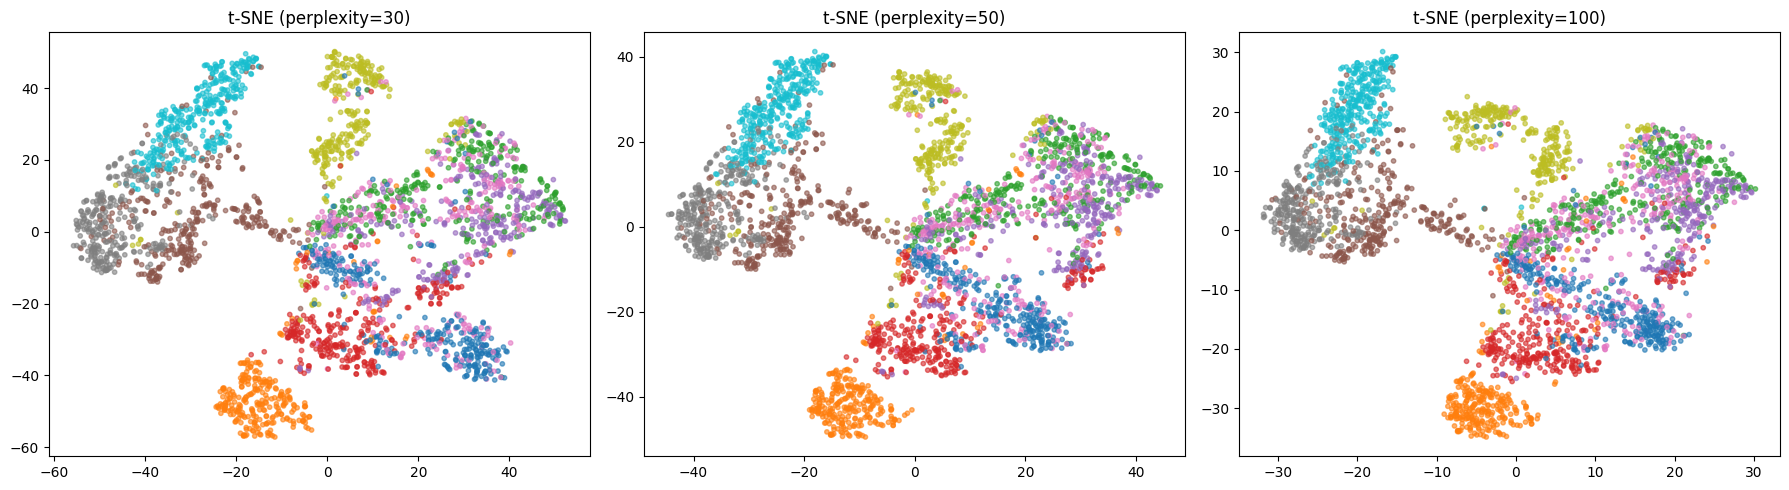

In [7]:
print("\n" + "=" * 50)
print("Part C: t-SNE Implementation")
print("=" * 50)

perplexities = [30, 50, 100]
tsne_results = {}
tsne_times = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 5))

for i, perplexity in enumerate(perplexities):
    start_time = time.time()

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_normalized)

    tsne_time = time.time() - start_time

    tsne_results[perplexity] = X_tsne
    tsne_times[perplexity] = tsne_time

    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
    axes[i].set_title(f't-SNE (perplexity={perplexity})')

plt.tight_layout()
plt.show()


Part D: Comparison
PCA time: 0.42 seconds
t-SNE (perp=30) time: 25.10 seconds
t-SNE (perp=50) time: 23.40 seconds
t-SNE (perp=100) time: 30.19 seconds


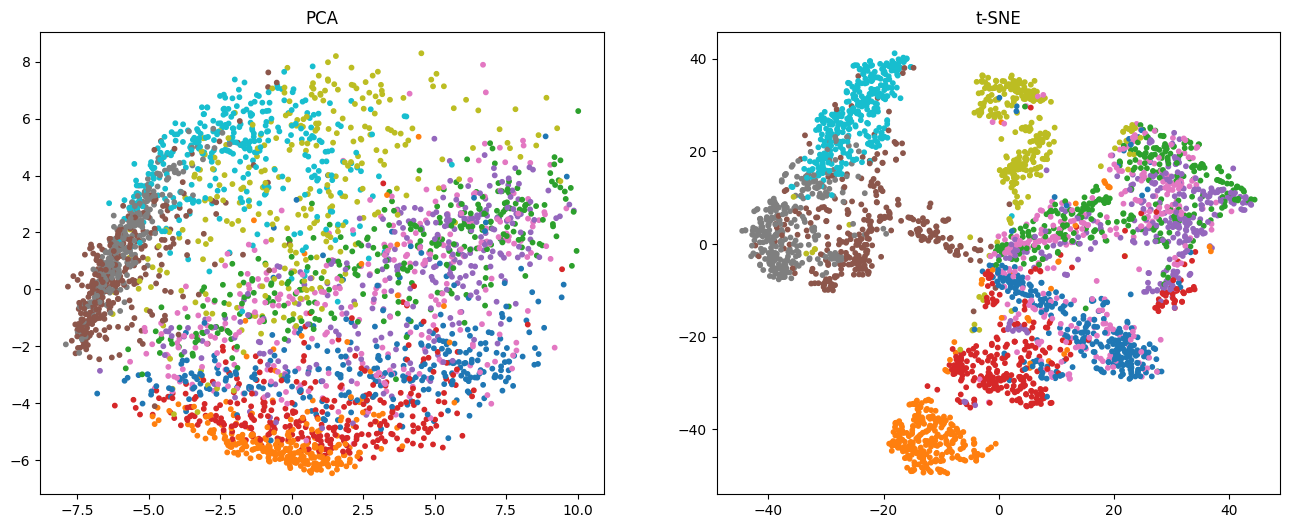

In [8]:
print("\n" + "=" * 50)
print("Part D: Comparison")
print("=" * 50)

print(f"PCA time: {pca_time:.2f} seconds")
for p, t in tsne_times.items():
    print(f"t-SNE (perp={p}) time: {t:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
axes[0].set_title('PCA')

best_perplexity = 50
axes[1].scatter(tsne_results[best_perplexity][:, 0],
                tsne_results[best_perplexity][:, 1],
                c=y, cmap='tab10', s=10)
axes[1].set_title('t-SNE')

plt.show()

In [9]:
def analyze_clusters(X_embedded, y_true, name):
    try:
        score = silhouette_score(X_embedded, y_true)
        print(f"{name} silhouette score: {score:.3f}")
    except:
        print(f"{name} failed")

print("\nCluster Analysis:")
analyze_clusters(X_pca, y, "PCA")

for p in perplexities:
    analyze_clusters(tsne_results[p], y, f"t-SNE ({p})")


Cluster Analysis:
PCA silhouette score: -0.036
t-SNE (30) silhouette score: 0.167
t-SNE (50) silhouette score: 0.177
t-SNE (100) silhouette score: 0.167
